# MMD distribution-distance extension for shallow masked diffusion

## Abstract
We extend the finite-sample train/test loss sanity check by testing a stronger empirical question: whether samples generated by a trained shallow masked diffusion sampler approach the true hidden-manifold distribution as the sample load $\alpha=M/D$ increases.

For each fixed latent dimension $D$, visible ratio $\gamma=N/D$, and sampled feature matrix $F$, the true data law is

$$
P_F: \quad z\sim\mathcal N(0,I_D),\qquad x=\operatorname{sign}(Fz)\in\{-1,+1\}^N.
$$

After training on $M=\alpha D$ samples from this same $P_F$, the learned model plus a specified unmasking sampler defines a generated law $P_{\theta,k}$. We estimate the discrepancy between $P_{\theta,k}$ and $P_F$ using Maximum Mean Discrepancy (MMD) with exponential normalized-Hamming kernels at several kernel scales.

As a empirical test we expect it to be close to the "true-true" baseline, if the capacity of the model is big enough.

## 1. Target distributional question

The original loss-convergence notebook asked whether empirical train loss and independent test loss approach each other.

In this case we have a stronger distribution questions:

$$
\operatorname{dist}(P_{\theta,k},P_F) \quad \text{as a function of}\quad \alpha=M/D.
$$

For each experiment we draw samples from two distributions:

1. **Model samples**: $x^{(s)}_{\mathrm{model}}\sim P_{\theta,k}$, obtained by running the trained masked-diffusion sampler.
2. **True samples**: $x^{(s)}_{\mathrm{true}}\sim P_F$, obtained by drawing fresh Gaussian latent vectors $z$ using the same feature matrix $F$ as the training set. It is of course essential to use the same $F$

Following the requested diagnostic, we estimate the distance using MMD with exponential Hamming kernels for several exponent coefficients that we have chosen:

$$
\lambda \in \{0.5,1,2,4,8,16\}.
$$

The main plot should show whether this estimated distance decreases as the sample load $\alpha=M/D$ increases. A decrease is the desired behavior; convergence to zero is not guaranteed for the linear shallow model but would be ideal.


## 2. Recap on the notation (not to get lost)
We now define

$$
\gamma=\frac{N}{D},\qquad \alpha=\frac{M}{D},
$$

where:

- $D$ is the latent hidden dimension;
- $N$ is the visible binary sequence length;
- $M$ is the number of training samples;
- $\gamma$ controls visible dimension relative to latent dimension;
- $\alpha$ controls sample load relative to latent dimension.

The codebase uses `L=N'. The repo training entry point uses the argument named `alpha` with

$$
M=\texttt{args.alpha}\cdot L,
$$

so the repo's command-line alpha is

$$
\alpha_{\mathrm{repo}}=\frac{M}{N}.
$$

In this notebook, `alpha` always means $\alpha=M/D$. Therefore when constructing the `MaskedDiffusion` config we pass

$$
\texttt{config.alpha}=\alpha_{\mathrm{repo}}=\frac{M}{N}=\frac{\alpha}{\gamma}.
$$

The true hidden-manifold generator is

$$
F_{ij}\sim\mathcal N(0,1/D),\qquad F\in\mathbb R^{N\times D},
$$

$$
z^\mu\sim\mathcal N(0,I_D),\qquad x^\mu=\operatorname{sign}(Fz^\mu)\in\{-1,+1\}^N.
$$

For each fixed $(D,\gamma,\text{repeat})$, the same sampled $F$ is used for training data, test data, and fresh true MMD reference samples. Thus the target is the finite-$F$ distribution $P_F$, not an average over new feature matrices.


## 3. Why MMD?

In high-dimensional discrete spaces $\{-1,+1\}^N$, direct KL-divergence or entropy-based comparisons are intractable because they require estimating probability masses over $2^N$ configurations. With finite samples, almost all configurations are unseen, causing severe support mismatch and bias.

MMD avoids explicit density estimation. It compares distributions through expectations of a kernel function evaluated on sample pairs. This makes it tractable for high-dimensional binary samples, although its sensitivity still depends strongly on the kernel scale, sample size, and estimator variance. We then use several exponential-Hamming kernel scales and always compare against "true-vs-true" / baseline and train-vs-true baselines.


## 4. Exponential Hamming Kernel

For binary vectors $x, y \in \{-1, +1\}^N$, the overlap (normalized inner product) is:
$$ q(x, y) = \frac{x \cdot y}{N} $$

The normalized Hamming distance is:
$$ \frac{d_H(x, y)}{N} = \frac{1 - q(x, y)}{2} $$

The exponential normalized-Hamming kernel with coefficient $\lambda > 0$ is defined as:
$$ k_\lambda(x, y) = \exp\left(-\lambda \frac{d_H(x, y)}{N}\right) = \exp\left(-\lambda \frac{1 - q(x, y)}{2}\right) $$

## 5. Estimator note: biased distance for plots, unbiased $MMD^2$ for statistics

We compute both the biased V-statistic and unbiased U-statistic estimators of $\mathrm{MMD}^2$.

### Biased $\mathrm{MMD}^2$ estimator (V-statistic)

$$
\widehat{\mathrm{MMD}}^2_{\lambda,\mathrm{biased}}(X,Y)
=
\frac{1}{m^2}\sum_{i,j}k_\lambda(X_i,X_j)
+
\frac{1}{n^2}\sum_{i,j}k_\lambda(Y_i,Y_j)
-
\frac{2}{mn}\sum_{i,j}k_\lambda(X_i,Y_j).
$$

For visualization we plot the non-negative biased MMD distance

$$
\mathrm{MMD}_{\lambda,\mathrm{biased}}
=
\sqrt{\max(0,\widehat{\mathrm{MMD}}^2_{\lambda,\mathrm{biased}})}.
$$

This is stable and easy to read, but it contains finite-sample diagonal terms. It should not be treated as a perfect noise-floor-corrected statistic.

### Unbiased $\mathrm{MMD}^2$ estimator (U-statistic)

$$
\widehat{\mathrm{MMD}}^2_{\lambda,\mathrm{unbiased}}(X,Y)
=
\frac{1}{m(m-1)}\sum_{i\ne j}k_\lambda(X_i,X_j)
+
\frac{1}{n(n-1)}\sum_{i\ne j}k_\lambda(Y_i,Y_j)
-
\frac{2}{mn}\sum_{i,j}k_\lambda(X_i,Y_j).
$$

The unbiased estimator has expectation zero when $X$ and $Y$ are independent samples from the same distribution, so finite-sample estimates can be slightly negative. We store raw unbiased values without clipping. Scientific interpretation should use the unbiased $MMD^2$ together with the true-vs-true and train-vs-true baselines.


## 6. Experimental setup

The experimental setup remains largely uncchanged:

- `model="linear"`;
- `freeze_mask_weights=True`, so the mask-indicator matrix $V$ is frozen at zero;
- `bias=False`;
- sampler default $k=1$, so one token is unmasked per update.

With this configuration, the effective logit is

$$
\operatorname{logit}_i(x_t)=\sum_{j=1}^N W_{ij}x_{t,j},
$$

where $x_{t,j}\in\{-1,0,+1\}$ and $0$ is the mask token.

The notebook supports two training objectives:

1. **`fixed_context`**: the finite-$K$ objective used to match the professor-style setup. We set $K=\kappa D$ visible coordinates in expectation, so
   $$
   t_{\mathrm{mask}}=1-K/N.
   $$
2. **`repo_uniform_t`**: the repo-style objective, where each batch samples $t\sim U(0,1)$ and applies Bernoulli masking with probability $t$.

The default remains `fixed_context` to preserve continuity with the loss-convergence sanity check. Switch to `repo_uniform_t` to test the canonical repo masked-diffusion objective.

We run 3 experiments:

1. **Experiment A**: clean target plot at fixed $(D,\gamma)$, varying $\alpha$.
2. **Experiment B**: controlled $D$ sweep at fixed $\gamma=2$.
3. **Experiment C**: optional $\gamma$ sweep at fixed $D$, useful because the professor's notation explicitly introduces $\gamma=N/D$.

For every row we compute:

- model-vs-true MMD: $\mathrm{MMD}(P_{\theta,k},P_F)$;
- true-vs-true MMD baseline: finite-sample comparison of two independent draws from $P_F$;
- train-vs-true MMD baseline: empirical training distribution compared with $P_F$;
- model-vs-train MMD diagnostic;
- nearest-neighbor overlap to the training set;
- optional pairwise-correlation error for the random-feature sign law.


## 7. Implementation

Here we configure the global execution parameters, including the `FAST_DEBUG` flag. We also define helper functions for training, evaluation, true sampling, and chunked MMD calculation.

In [ ]:
import os
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from types import SimpleNamespace
from torch.utils.data import Subset, DataLoader
from pathlib import Path

current_dir = Path.cwd()
project_root = None
for path in [current_dir, current_dir.parent] + list(current_dir.parents):
    if (path / "datasets.py").exists() and (path / "diffusion.py").exists():
        project_root = path.resolve()
        break

if project_root is None:
    raise FileNotFoundError("Could not find project root containing datasets.py and diffusion.py")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from datasets import RandomFeaturesDataset
from diffusion import MaskedDiffusion

os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

In [ ]:
# MMD evaluation parameters
mmd_lambdas = [0.5, 1.0, 2.0, 4.0, 8.0, 16.0]
mmd_chunk_size = 1024
kappa = 0.5
M_test = 1000
n_eval_mc = 50

# Training objective:
# - "fixed_context": finite-K objective used in the loss-convergence sanity check.
# - "repo_uniform_t": repo-style objective, t ~ Uniform(0,1), Bernoulli mask, 1/t weighting.
TRAINING_OBJECTIVE = "fixed_context"

# Sampler: generated law is P_{theta,k}. k=1 is the default sequential sampler.
sample_k = 1

# Set FINAL_RUN=True for multiple repeats. False is faster. 
FINAL_RUN = False

# True to test gamma=N/D.
RUN_GAMMA_SWEEP = True

# Pairwise correlation is cheap compared with MMD for the current N, so we can compute it. 
COMPUTE_CORRELATION_DIAGNOSTIC = True

# FAST_DEBUG switch for quick verification.
# REMEMBER TO TURN IT OFF before launching the experiment!!
FAST_DEBUG = False

if FAST_DEBUG:
    print("FAST_DEBUG mode active: using reduced parameters.")
    n_mmd_samples = 1000
    num_steps = 300
    n_repeats = 1
    Experiment_A_configs = [(40, 2.0, alpha) for alpha in [0.5, 2.0, 10.0]]
    Experiment_B_configs = [(D, 2.0, alpha) for D in [40, 80] for alpha in [0.5, 2.0, 10.0]]
    Experiment_C_configs = [(40, gamma, alpha) for gamma in [1.0, 2.0] for alpha in [0.5, 2.0, 10.0]] if RUN_GAMMA_SWEEP else []
else:
    n_mmd_samples = 10000
    num_steps = 3000
    n_repeats = 3 if FINAL_RUN else 1
    Experiment_A_configs = [(80, 2.0, alpha) for alpha in [0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0]]
    Experiment_B_configs = [(D, 2.0, alpha) for D in [40, 80, 160] for alpha in [0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]]
    Experiment_C_configs = [(80, gamma, alpha) for gamma in [1.0, 2.0, 4.0] for alpha in [1.0, 2.0, 5.0, 10.0, 20.0, 50.0]] if RUN_GAMMA_SWEEP else []

# Reproducibility
base_seed = 42
torch.manual_seed(base_seed)
np.random.seed(base_seed)

# Device configuration
mmd_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {mmd_device}")
print(f"TRAINING_OBJECTIVE: {TRAINING_OBJECTIVE}")
print(f"sample_k: {sample_k}")
print(f"n_repeats: {n_repeats}")
print(f"RUN_GAMMA_SWEEP: {RUN_GAMMA_SWEEP}")


Using device: cpu
TRAINING_OBJECTIVE: fixed_context
sample_k: 1
n_repeats: 1
RUN_GAMMA_SWEEP: True


In [3]:
def train_model(train_dataset, config, num_steps, training_objective="fixed_context", t_mask=None, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)

    if training_objective not in {"fixed_context", "repo_uniform_t"}:
        raise ValueError(f"Unknown training_objective={training_objective}")
    if training_objective == "fixed_context" and t_mask is None:
        raise ValueError("fixed_context training requires t_mask")

    model = MaskedDiffusion(config)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=0.0)
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)

    model.train()
    step = 0
    iterator = iter(train_loader)

    losses = []
    while step < num_steps:
        try:
            batch = next(iterator)
        except StopIteration:
            iterator = iter(train_loader)
            batch = next(iterator)

        optimizer.zero_grad()
        loss_t = t_mask if training_objective == "fixed_context" else None
        loss, acc = model._compute_loss(batch, t=loss_t)
        total_loss = loss + model.l2coeff * model.sqnorm()

        total_loss.backward()
        optimizer.step()

        losses.append(total_loss.item())
        if (step + 1) % 500 == 0:
            avg_loss = np.mean(losses[-100:])
            print(f"    Step {step+1}/{num_steps} | Loss: {avg_loss:.4f}")

        step += 1

    return model

@torch.no_grad()
def evaluate_model(model, dataset, mc_samples, t_mask):
    model.eval()
    loader = DataLoader(dataset, batch_size=len(dataset), shuffle=False)
    batch = next(iter(loader))
    loss, acc = model._compute_loss(batch, t=t_mask, mc_samples=mc_samples)
    return loss.item(), acc

def sample_true_from_fixed_F(F, n_samples, seed=None, device=None):
    if device is None:
        device = F.device

    if seed is not None:
        generator = torch.Generator(device=device).manual_seed(seed)
    else:
        generator = None

    N_dim, D_dim = F.shape
    F_dev = F.to(device)
    z = torch.randn((n_samples, D_dim), device=device, generator=generator)
    x = torch.sign(z @ F_dev.t())
    x[x == 0.0] = 1.0
    return x.cpu().to(torch.float32)

@torch.no_grad()
def sample_model(model, n_samples, k=1):
    model.eval()
    with torch.inference_mode():
        x_model = model.sample(n_samples, k=k).cpu()
    assert x_model.ndim == 2, f"Expected 2D tensor, got shape {x_model.shape}"
    assert x_model.shape[0] == n_samples
    assert torch.all((x_model == 1.0) | (x_model == -1.0)), "Model samples contain non-binary values!"
    return x_model.to(torch.float32)

def kernel_sums_exponential_hamming(X, Y, lambdas, chunk_size=1024, device=None, exclude_diagonal=False):
    m = X.shape[0]
    n = Y.shape[0]

    sums = {lam: 0.0 for lam in lambdas}

    if device is None:
        device = X.device

    X_dev = X.to(device=device, dtype=torch.float32)
    Y_dev = Y.to(device=device, dtype=torch.float32)
    N_dim = X.shape[1]

    for i_start in range(0, m, chunk_size):
        i_end = min(i_start + chunk_size, m)
        X_chunk = X_dev[i_start:i_end]

        for j_start in range(0, n, chunk_size):
            j_end = min(j_start + chunk_size, n)
            Y_chunk = Y_dev[j_start:j_end]

            overlaps = torch.matmul(X_chunk, Y_chunk.t()) / N_dim
            norm_hamming = (1.0 - overlaps) / 2.0

            for lam in lambdas:
                kernel_vals = torch.exp(-lam * norm_hamming)

                if exclude_diagonal and X is Y and i_start == j_start:
                    min_len = min(i_end - i_start, j_end - j_start)
                    block_diag_sum = torch.diagonal(kernel_vals[:min_len, :min_len]).sum().item()
                    sums[lam] += (kernel_vals.sum().item() - block_diag_sum)
                else:
                    sums[lam] += kernel_vals.sum().item()

    return sums

def compute_mmd_biased_unbiased(X, Y, lambdas, chunk_size=1024, device=None):
    m = len(X)
    n = len(Y)

    # Biased sums
    sum_xx_biased = kernel_sums_exponential_hamming(X, X, lambdas, chunk_size=chunk_size, device=device, exclude_diagonal=False)
    sum_yy_biased = kernel_sums_exponential_hamming(Y, Y, lambdas, chunk_size=chunk_size, device=device, exclude_diagonal=False)
    sum_xy = kernel_sums_exponential_hamming(X, Y, lambdas, chunk_size=chunk_size, device=device, exclude_diagonal=False)

    # Unbiased sums
    sum_xx_unbiased = kernel_sums_exponential_hamming(X, X, lambdas, chunk_size=chunk_size, device=device, exclude_diagonal=True)
    sum_yy_unbiased = kernel_sums_exponential_hamming(Y, Y, lambdas, chunk_size=chunk_size, device=device, exclude_diagonal=True)

    results = {}
    biased_vals = []
    unbiased_vals = []

    for lam in lambdas:
        val_xx = sum_xx_biased[lam] / (m * m)
        val_yy = sum_yy_biased[lam] / (n * n)
        val_xy = sum_xy[lam] / (m * n)
        mmd2_biased = val_xx + val_yy - 2.0 * val_xy

        val_xx_u = sum_xx_unbiased[lam] / (m * (m - 1)) if m > 1 else 0.0
        val_yy_u = sum_yy_unbiased[lam] / (n * (n - 1)) if n > 1 else 0.0
        mmd2_unbiased = val_xx_u + val_yy_u - 2.0 * val_xy

        key_lam = "0_5" if lam == 0.5 else f"{int(lam)}"

        results[f"mmd2_biased_lambda_{key_lam}"] = mmd2_biased
        results[f"mmd2_unbiased_lambda_{key_lam}_raw"] = mmd2_unbiased
        results[f"mmd_biased_lambda_{key_lam}"] = np.sqrt(max(mmd2_biased, 0.0))

        biased_vals.append(mmd2_biased)
        unbiased_vals.append(mmd2_unbiased)

    results["mmd2_biased_multiscale"] = np.mean(biased_vals)
    results["mmd2_unbiased_multiscale_raw"] = np.mean(unbiased_vals)
    results["mmd_biased_multiscale"] = np.sqrt(max(np.mean(biased_vals), 0.0))

    return results

@torch.no_grad()
def topk_train_overlaps(samples, train_data, k=3, chunk_size=1024, device=None):
    if device is None:
        device = samples.device

    samples = samples.to(device=device, dtype=torch.float32)
    train_data = train_data.to(device=device, dtype=torch.float32)
    N_dim = samples.shape[1]
    topk_vals = []

    for start in range(0, samples.shape[0], chunk_size):
        end = min(start + chunk_size, samples.shape[0])
        q = samples[start:end] @ train_data.t() / N_dim
        vals = q.topk(min(k, train_data.shape[0]), dim=1).values
        topk_vals.append(vals.cpu())

    topk_vals = torch.cat(topk_vals, dim=0)
    out = {
        "nearest_train_q1_mean": topk_vals[:, 0].mean().item(),
        "nearest_train_q1_std": topk_vals[:, 0].std().item(),
    }
    if topk_vals.shape[1] >= 2:
        out["nearest_train_q2_mean"] = topk_vals[:, 1].mean().item()
        out["nearest_train_q1_q2_gap_mean"] = (topk_vals[:, 0] - topk_vals[:, 1]).mean().item()
    else:
        out["nearest_train_q2_mean"] = np.nan
        out["nearest_train_q1_q2_gap_mean"] = np.nan
    return out

@torch.no_grad()
def true_rf_sign_correlation(F):
    F = F.float()
    norms = F.norm(dim=1, keepdim=True).clamp_min(1e-12)
    F_norm = F / norms
    rho = (F_norm @ F_norm.t()).clamp(-1.0, 1.0)
    return (2.0 / np.pi) * torch.arcsin(rho)

@torch.no_grad()
def empirical_correlation(X):
    X = X.float()
    return (X.t() @ X) / X.shape[0]

@torch.no_grad()
def offdiag_frobenius_relative_error(C_hat, C_true):
    mask = ~torch.eye(C_true.shape[0], dtype=torch.bool, device=C_true.device)
    num = torch.norm((C_hat - C_true)[mask])
    den = torch.norm(C_true[mask]).clamp_min(1e-12)
    return (num / den).item()

def grouped_mean_sem(df, group_cols, value_col):
    g = df.groupby(group_cols)[value_col]
    out = g.mean().reset_index(name="mean")
    sem = g.sem().reset_index(name="sem")
    return out.merge(sem, on=group_cols)


## 8. Sanity Checks

We perform diagnostic sanity checks to verify the correctness of the generated samples and the implementation of biased and unbiased estimators.

In [4]:
print("Running MMD sanity checks...")
temp_N = 80
temp_D = 20
temp_dataset = RandomFeaturesDataset(n_visible=temp_N, n_hidden=temp_D, num_samples=2000, act=torch.sign)

# 1. Fixed F assertion check
print("Sanity check: generating true samples from dataset F (no new RandomFeaturesDataset)")
X1 = sample_true_from_fixed_F(temp_dataset.F, n_samples=1000, seed=42)
X2 = sample_true_from_fixed_F(temp_dataset.F, n_samples=1000, seed=43)

# 2. Shapes check
assert X1.shape == (1000, temp_N), f"Incorrect shape: {X1.shape}"
assert X2.shape == (1000, temp_N)

# 3. Binary values check
assert torch.all((X1 == 1.0) | (X1 == -1.0)), "X1 contains non-binary values!"
assert torch.all((X2 == 1.0) | (X2 == -1.0)), "X2 contains non-binary values!"

# 4. Biased self-MMD check (should be exactly zero)
self_mmd_res = compute_mmd_biased_unbiased(X1, X1, mmd_lambdas, chunk_size=mmd_chunk_size, device=mmd_device)
print("\nSelf-MMD results (biased vs unbiased):")
for lam in mmd_lambdas:
    key_lam = "0_5" if lam == 0.5 else f"{int(lam)}"
    biased_val = self_mmd_res[f"mmd2_biased_lambda_{key_lam}"]
    unbiased_val = self_mmd_res[f"mmd2_unbiased_lambda_{key_lam}_raw"]
    dist_val = self_mmd_res[f"mmd_biased_lambda_{key_lam}"]
    print(f"  λ = {lam:4.1f} | Biased MMD2: {biased_val:10.6e} | Unbiased MMD2: {unbiased_val:10.6e} | MMD Dist: {dist_val:10.6e}")
    # Biased self-MMD must be zero (with numerical tolerance)
    assert abs(biased_val) < 1e-5, f"Biased self-MMD is not zero: {biased_val}"
    assert abs(dist_val) < 1e-3, f"MMD self-distance is not zero: {dist_val}"

print(f"  Multiscale | Biased: {self_mmd_res['mmd2_biased_multiscale']:10.6e} | Unbiased: {self_mmd_res['mmd2_unbiased_multiscale_raw']:10.6e}")
assert abs(self_mmd_res["mmd2_biased_multiscale"]) < 1e-5, "Biased multiscale self-MMD is not zero"

# 5. Independent samples check (unbiased self-MMD printed, can be negative)
indep_mmd_res = compute_mmd_biased_unbiased(X1, X2, mmd_lambdas, chunk_size=mmd_chunk_size, device=mmd_device)
print("\nIndependent samples MMD (noise floor):")
for lam in mmd_lambdas:
    key_lam = "0_5" if lam == 0.5 else f"{int(lam)}"
    biased_val = indep_mmd_res[f"mmd2_biased_lambda_{key_lam}"]
    unbiased_val = indep_mmd_res[f"mmd2_unbiased_lambda_{key_lam}_raw"]
    print(f"  λ = {lam:4.1f} | Biased MMD2: {biased_val:10.6e} | Unbiased MMD2: {unbiased_val:10.6e}")

print("\nMMD sanity checks completed successfully!")

Running MMD sanity checks...
Sanity check: generating true samples from dataset F (no new RandomFeaturesDataset)

Self-MMD results (biased vs unbiased):
  λ =  0.5 | Biased MMD2: 0.000000e+00 | Unbiased MMD2: -4.407777e-04 | MMD Dist: 0.000000e+00
  λ =  1.0 | Biased MMD2: 0.000000e+00 | Unbiased MMD2: -7.818039e-04 | MMD Dist: 0.000000e+00
  λ =  2.0 | Biased MMD2: 0.000000e+00 | Unbiased MMD2: -1.251612e-03 | MMD Dist: 0.000000e+00
  λ =  4.0 | Biased MMD2: 0.000000e+00 | Unbiased MMD2: -1.710212e-03 | MMD Dist: 0.000000e+00
  λ =  8.0 | Biased MMD2: 0.000000e+00 | Unbiased MMD2: -1.951908e-03 | MMD Dist: 0.000000e+00
  λ = 16.0 | Biased MMD2: 0.000000e+00 | Unbiased MMD2: -1.998043e-03 | MMD Dist: 0.000000e+00
  Multiscale | Biased: 0.000000e+00 | Unbiased: -1.355726e-03

Independent samples MMD (noise floor):
  λ =  0.5 | Biased MMD2: 3.301875e-04 | Unbiased MMD2: -1.106803e-04
  λ =  1.0 | Biased MMD2: 6.147500e-04 | Unbiased MMD2: -1.672051e-04
  λ =  2.0 | Biased MMD2: 1.060406e

## 9. Sweep Execution

We run a unified parameter sweep to collect data for both Experiment A and Experiment B. The configurations are matched based on the active mode (`FAST_DEBUG`). The trained models and MMD calculations are optimized to avoid duplicate runs.

In [5]:
# Combine configurations to avoid duplicate training.
# Note: repeats are handled explicitly; duplicate configs across A/B/C are trained once per repeat.
all_configs = sorted(list(set(Experiment_A_configs + Experiment_B_configs + Experiment_C_configs)))

results_list = []
dataset_cache = {}
baseline_cache = {}

def get_dataset_and_baseline(D, gamma, repeat):
    key = (D, gamma, repeat)
    if key in dataset_cache:
        return dataset_cache[key], baseline_cache[key]

    N = int(round(gamma * D))
    alphas_for_dg = [cfg[2] for cfg in all_configs if cfg[0] == D and cfg[1] == gamma]
    max_alpha_dg = max(alphas_for_dg)
    M_max = int(round(max_alpha_dg * D))

    dataset_seed = base_seed + 100000 * repeat + int(gamma * 100) + int(D * 10)
    torch.manual_seed(dataset_seed)
    np.random.seed(dataset_seed)

    full_dataset = RandomFeaturesDataset(
        n_visible=N,
        n_hidden=D,
        num_samples=M_max + M_test,
        act=torch.sign,
    )
    assert torch.all((full_dataset.data == 1.0) | (full_dataset.data == -1.0))

    print(f"\nCaching True-vs-True baseline for D={D}, gamma={gamma:.1f}, repeat={repeat}...")
    x_true_a = sample_true_from_fixed_F(full_dataset.F, n_samples=n_mmd_samples, seed=dataset_seed + 100, device=mmd_device)
    x_true_b = sample_true_from_fixed_F(full_dataset.F, n_samples=n_mmd_samples, seed=dataset_seed + 200, device=mmd_device)
    baseline_mmd = compute_mmd_biased_unbiased(
        x_true_a,
        x_true_b,
        mmd_lambdas,
        chunk_size=mmd_chunk_size,
        device=mmd_device,
    )

    dataset_cache[key] = {
        "full_dataset": full_dataset,
        "M_max": M_max,
        "dataset_seed": dataset_seed,
    }
    baseline_cache[key] = baseline_mmd
    return dataset_cache[key], baseline_mmd

for repeat in range(n_repeats):
    for (D, gamma, alpha) in all_configs:
        N = int(round(gamma * D))

        # Expected visible context size for the fixed-context objective.
        K = int(round(kappa * D))
        t_mask_val = 1.0 - (K / N)

        assert 0 < K < N, f"K ({K}) must be strictly between 0 and N ({N})"
        assert 0.0 < t_mask_val < 1.0, f"t_mask_val ({t_mask_val}) must be strictly between 0.0 and 1.0"

        dataset_info, baseline_mmd = get_dataset_and_baseline(D, gamma, repeat)
        full_dataset = dataset_info["full_dataset"]
        M_max = dataset_info["M_max"]
        dataset_seed = dataset_info["dataset_seed"]

        test_dataset = Subset(full_dataset, list(range(M_max, M_max + M_test)))
        M_train = int(round(alpha * D))
        alpha_code = M_train / N
        train_dataset = Subset(full_dataset, list(range(M_train)))

        config = SimpleNamespace(
            L=N,
            alpha=alpha_code,
            model="linear",
            l2reg=0.0,
            lr=0.005,
            epochs=1,
            batch_size=min(M_train, 512),
            freeze_mask_weights=True,
            bias=False,
            pbar=False,
        )

        model_seed = base_seed + 200000 * repeat + int(gamma * 1000) + int(D * 500) + int(alpha * 10)

        print(
            f"Training D={D}, gamma={gamma:.1f}, alpha={alpha:5.1f} "
            f"(M_train={M_train:4d}, repeat={repeat}, objective={TRAINING_OBJECTIVE}) ..."
        )
        model = train_model(
            train_dataset,
            config,
            num_steps,
            training_objective=TRAINING_OBJECTIVE,
            t_mask=t_mask_val,
            seed=model_seed,
        )

        # Evaluate loss at the fixed-context mask level for continuity with the old loss notebook.
        train_loss, train_acc = evaluate_model(model, train_dataset, n_eval_mc, t_mask=t_mask_val)
        test_loss, test_acc = evaluate_model(model, test_dataset, n_eval_mc, t_mask=t_mask_val)
        loss_gap = test_loss - train_loss

        # Generate model samples. The generated law is P_{theta,k}.
        model = model.to(mmd_device)
        x_model = sample_model(model, n_samples=n_mmd_samples, k=sample_k)
        model = model.to("cpu")

        # Generate fresh true samples from the same fixed F.
        x_true = sample_true_from_fixed_F(full_dataset.F, n_samples=n_mmd_samples, seed=model_seed + 300, device=mmd_device)

        # Resample empirical training distribution with replacement.
        X_train = full_dataset.data[:M_train]
        rng = np.random.default_rng(model_seed + 400)
        train_indices = rng.choice(M_train, size=n_mmd_samples, replace=True)
        x_train_empirical = X_train[train_indices]

        # Main and baseline MMD diagnostics.
        mmd_model_true = compute_mmd_biased_unbiased(x_model, x_true, mmd_lambdas, chunk_size=mmd_chunk_size, device=mmd_device)
        mmd_model_train = compute_mmd_biased_unbiased(x_model, x_train_empirical, mmd_lambdas, chunk_size=mmd_chunk_size, device=mmd_device)
        mmd_train_true = compute_mmd_biased_unbiased(x_train_empirical, x_true, mmd_lambdas, chunk_size=mmd_chunk_size, device=mmd_device)

        # Direct memorization proxy: nearest training overlaps.
        nn_stats = topk_train_overlaps(x_model, X_train, k=3, chunk_size=mmd_chunk_size, device=mmd_device)

        # Optional structural diagnostic: RF-sign pairwise correlation recovery.
        corr_stats = {}
        if COMPUTE_CORRELATION_DIAGNOSTIC:
            C_true = true_rf_sign_correlation(full_dataset.F)
            C_model = empirical_correlation(x_model)
            C_fresh = empirical_correlation(x_true)
            corr_stats["corr_relerr_model_true"] = offdiag_frobenius_relative_error(C_model, C_true)
            corr_stats["corr_relerr_fresh_true"] = offdiag_frobenius_relative_error(C_fresh, C_true)

        print(f"  BCE Loss: Train {train_loss:.4f} | Test {test_loss:.4f}")
        print(
            f"  MMD Dist: Model-True {mmd_model_true['mmd_biased_multiscale']:.5f} | "
            f"Train-True {mmd_train_true['mmd_biased_multiscale']:.5f} | "
            f"True-True {baseline_mmd['mmd_biased_multiscale']:.5f}"
        )

        experiments_to_save = []
        if (D, gamma, alpha) in Experiment_A_configs:
            experiments_to_save.append("A")
        if (D, gamma, alpha) in Experiment_B_configs:
            experiments_to_save.append("B")
        if (D, gamma, alpha) in Experiment_C_configs:
            experiments_to_save.append("C")

        for exp in experiments_to_save:
            res = {
                "experiment": exp,
                "repeat": repeat,
                "seed": model_seed,
                "dataset_seed": dataset_seed,
                "training_objective": TRAINING_OBJECTIVE,
                "sample_k": sample_k,
                "D": D,
                "gamma": gamma,
                "N": N,
                "alpha": alpha,
                "M_train": M_train,
                "M_test": M_test,
                "alpha_code": alpha_code,
                "kappa": kappa,
                "K_visible_expected": K,
                "t_mask_val": t_mask_val,
                "n_mmd_samples": n_mmd_samples,
                "num_steps": num_steps,
                "train_loss": train_loss,
                "test_loss": test_loss,
                "loss_gap": loss_gap,
                "abs_loss_gap": abs(loss_gap),
                "train_acc": train_acc,
                "test_acc": test_acc,

                # Model-vs-True: primary target diagnostic.
                "mmd_biased_multiscale": mmd_model_true["mmd_biased_multiscale"],
                "mmd2_biased_multiscale": mmd_model_true["mmd2_biased_multiscale"],
                "mmd2_unbiased_multiscale_raw": mmd_model_true["mmd2_unbiased_multiscale_raw"],

                # True-vs-True finite-sample baseline.
                "baseline_mmd_biased_multiscale": baseline_mmd["mmd_biased_multiscale"],
                "baseline_mmd2_biased_multiscale": baseline_mmd["mmd2_biased_multiscale"],
                "baseline_mmd2_unbiased_multiscale_raw": baseline_mmd["mmd2_unbiased_multiscale_raw"],

                # Train-vs-True empirical baseline.
                "train_true_mmd_biased_multiscale": mmd_train_true["mmd_biased_multiscale"],
                "train_true_mmd2_biased_multiscale": mmd_train_true["mmd2_biased_multiscale"],
                "train_true_mmd2_unbiased_multiscale_raw": mmd_train_true["mmd2_unbiased_multiscale_raw"],

                # Model-vs-Train empirical proximity diagnostic.
                "model_train_mmd_biased_multiscale": mmd_model_train["mmd_biased_multiscale"],
                "model_train_mmd2_biased_multiscale": mmd_model_train["mmd2_biased_multiscale"],
                "model_train_mmd2_unbiased_multiscale_raw": mmd_model_train["mmd2_unbiased_multiscale_raw"],
            }
            res.update(nn_stats)
            res.update(corr_stats)

            # Backward-compatible alias for old plots.
            res["train_empirical_mmd_biased_multiscale"] = res["model_train_mmd_biased_multiscale"]

            # Lambda-specific columns.
            for lam in mmd_lambdas:
                key_lam = "0_5" if lam == 0.5 else f"{int(lam)}"

                # Model-vs-True.
                res[f"mmd_biased_lambda_{key_lam}"] = mmd_model_true[f"mmd_biased_lambda_{key_lam}"]
                res[f"mmd2_biased_lambda_{key_lam}"] = mmd_model_true[f"mmd2_biased_lambda_{key_lam}"]
                res[f"mmd2_unbiased_lambda_{key_lam}_raw"] = mmd_model_true[f"mmd2_unbiased_lambda_{key_lam}_raw"]

                # True-vs-True.
                res[f"baseline_mmd_biased_lambda_{key_lam}"] = baseline_mmd[f"mmd_biased_lambda_{key_lam}"]
                res[f"baseline_mmd2_biased_lambda_{key_lam}"] = baseline_mmd[f"mmd2_biased_lambda_{key_lam}"]
                res[f"baseline_mmd2_unbiased_lambda_{key_lam}_raw"] = baseline_mmd[f"mmd2_unbiased_lambda_{key_lam}_raw"]

                # Model-vs-Train.
                res[f"model_train_mmd_biased_lambda_{key_lam}"] = mmd_model_train[f"mmd_biased_lambda_{key_lam}"]
                res[f"model_train_mmd2_biased_lambda_{key_lam}"] = mmd_model_train[f"mmd2_biased_lambda_{key_lam}"]
                res[f"model_train_mmd2_unbiased_lambda_{key_lam}_raw"] = mmd_model_train[f"mmd2_unbiased_lambda_{key_lam}_raw"]

                # Train-vs-True.
                res[f"train_true_mmd_biased_lambda_{key_lam}"] = mmd_train_true[f"mmd_biased_lambda_{key_lam}"]
                res[f"train_true_mmd2_biased_lambda_{key_lam}"] = mmd_train_true[f"mmd2_biased_lambda_{key_lam}"]
                res[f"train_true_mmd2_unbiased_lambda_{key_lam}_raw"] = mmd_train_true[f"mmd2_unbiased_lambda_{key_lam}_raw"]

                # Old aliases.
                res[f"train_mmd_biased_lambda_{key_lam}"] = res[f"model_train_mmd_biased_lambda_{key_lam}"]
                res[f"train_mmd2_biased_lambda_{key_lam}"] = res[f"model_train_mmd2_biased_lambda_{key_lam}"]
                res[f"train_mmd2_unbiased_lambda_{key_lam}_raw"] = res[f"model_train_mmd2_unbiased_lambda_{key_lam}_raw"]

            results_list.append(res)

        pd.DataFrame(results_list).to_csv("results/results_mmd_distribution_distance.csv", index=False)



Caching True-vs-True baseline for D=40, gamma=2.0, repeat=0...
Training D=40, gamma=2.0, alpha=  0.5 (M_train=  20, repeat=0, objective=fixed_context) ...
    Step 500/3000 | Loss: 0.3245
    Step 1000/3000 | Loss: 0.3073
    Step 1500/3000 | Loss: 0.3041
    Step 2000/3000 | Loss: 0.3035
    Step 2500/3000 | Loss: 0.3047
    Step 3000/3000 | Loss: 0.2998
  BCE Loss: Train 0.3067 | Test 1.0772
  MMD Dist: Model-True 0.06380 | Train-True 0.18238 | True-True 0.01131
Training D=40, gamma=2.0, alpha=  1.0 (M_train=  40, repeat=0, objective=fixed_context) ...
    Step 500/3000 | Loss: 0.4402
    Step 1000/3000 | Loss: 0.4302
    Step 1500/3000 | Loss: 0.4275
    Step 2000/3000 | Loss: 0.4336
    Step 2500/3000 | Loss: 0.4324
    Step 3000/3000 | Loss: 0.4316
  BCE Loss: Train 0.4315 | Test 0.8287
  MMD Dist: Model-True 0.05121 | Train-True 0.12652 | True-True 0.01131
Training D=40, gamma=2.0, alpha=  2.0 (M_train=  80, repeat=0, objective=fixed_context) ...
    Step 500/3000 | Loss: 0.5144

In [6]:
df = pd.DataFrame(results_list)
df.to_csv("results/results_mmd_distribution_distance.csv", index=False)
print(f"Saved {len(df)} rows of results.")
df.head()

Saved 47 rows of results.


,experiment,repeat,seed,dataset_seed,training_objective,sample_k,D,gamma,N,alpha,...,baseline_mmd2_unbiased_lambda_16_raw,model_train_mmd_biased_lambda_16,model_train_mmd2_biased_lambda_16,model_train_mmd2_unbiased_lambda_16_raw,train_true_mmd_biased_lambda_16,train_true_mmd2_biased_lambda_16,train_true_mmd2_unbiased_lambda_16_raw,train_mmd_biased_lambda_16,train_mmd2_biased_lambda_16,train_mmd2_unbiased_lambda_16_raw
0,B,0,22047,642,fixed_context,1,40,2.0,80,0.5,...,-1.916988e-07,0.218981,0.047953,0.047758,0.223758,0.050068,0.049873,0.218981,0.047953,0.047758
1,B,0,22052,642,fixed_context,1,40,2.0,80,1.0,...,-1.916988e-07,0.156372,0.024452,0.024255,0.158480,0.025116,0.024918,0.156372,0.024452,0.024255
2,B,0,22062,642,fixed_context,1,40,2.0,80,2.0,...,-1.916988e-07,0.111236,0.012373,0.012175,0.112504,0.012657,0.012458,0.111236,0.012373,0.012175
3,B,0,22092,642,fixed_context,1,40,2.0,80,5.0,...,-1.916988e-07,0.071286,0.005082,0.004882,0.071932,0.005174,0.004975,0.071286,0.005082,0.004882
4,B,0,22142,642,fixed_context,1,40,2.0,80,10.0,...,-1.916988e-07,0.051541,0.002657,0.002457,0.051908,0.002694,0.002495,0.051541,0.002657,0.002457


## 10. Main result (Experiment A)

Experiment A plots MMD distance against the professor's sample load $\alpha=M/D$ at fixed $(D,\gamma)$.

Curves shown:

- **Model vs True**: generated samples from $P_{\theta,k}$ compared with fresh samples from $P_F$.
- **True vs True**: finite-sample noise baseline from two independent fresh batches from $P_F$.
- **Train vs True**: empirical training distribution compared with $P_F$.

The desired sanity-check behavior is that Model-vs-True decreases as $\alpha$ increases. If it plateaus above True-vs-True, that is compatible with model misspecification, but it is not by itself proof of a capacity limit.


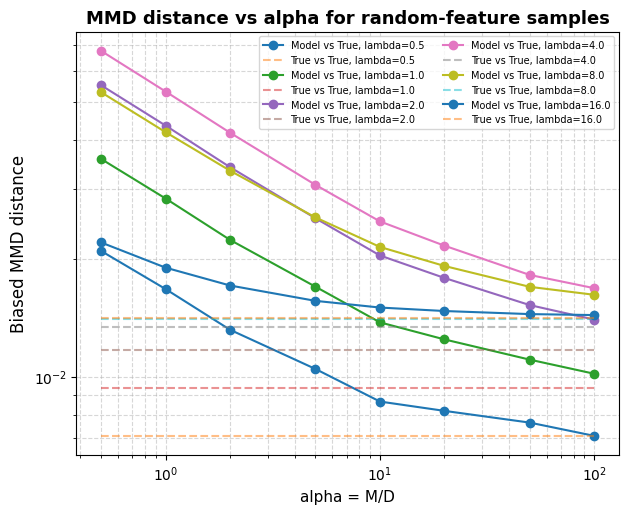

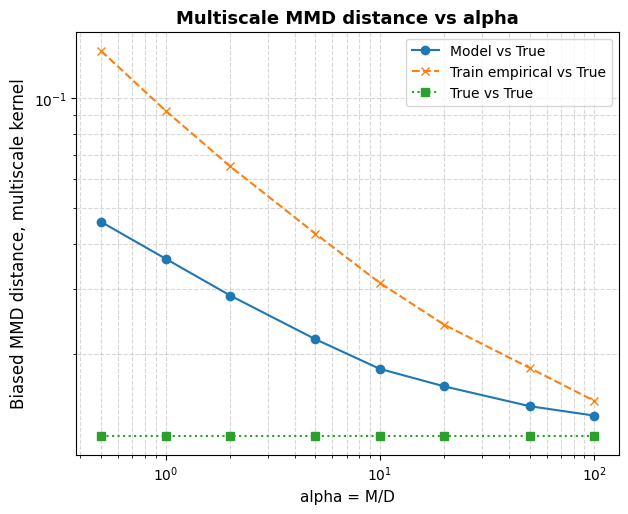

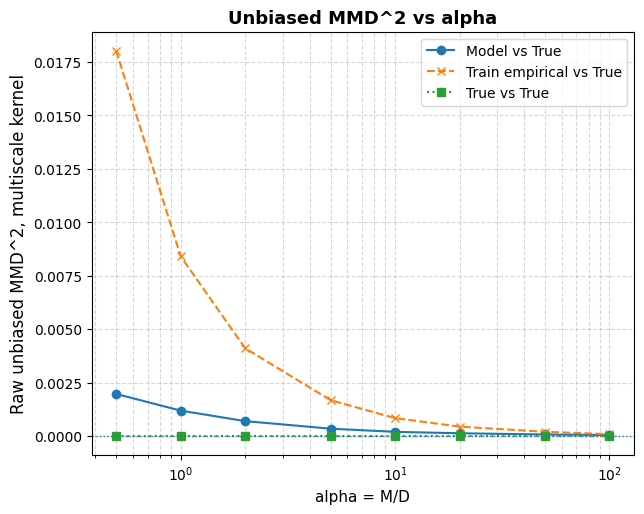

In [7]:
df_A = df[df["experiment"] == "A"].copy()

if not df_A.empty:
    # Plot 1: lambda-specific target plot. Average over repeats if present.
    plt.figure(figsize=(7, 5.5))

    for lam in mmd_lambdas:
        key_lam = "0_5" if lam == 0.5 else f"{int(lam)}"
        col_name = f"mmd_biased_lambda_{key_lam}"
        base_col = f"baseline_mmd_biased_lambda_{key_lam}"

        sub = grouped_mean_sem(df_A, ["alpha"], col_name).sort_values("alpha")
        base = grouped_mean_sem(df_A, ["alpha"], base_col).sort_values("alpha")

        plt.plot(sub["alpha"], sub["mean"], linestyle="-", marker="o", label=f"Model vs True, lambda={lam}")
        plt.plot(base["alpha"], base["mean"], linestyle="--", alpha=0.5, label=f"True vs True, lambda={lam}")

    plt.xscale("log")
    plt.yscale("log", nonpositive="clip")
    plt.xlabel("alpha = M/D", fontsize=11)
    plt.ylabel("Biased MMD distance", fontsize=12)
    plt.title("MMD distance vs alpha for random-feature samples", fontsize=13, fontweight="bold")
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.legend(loc="best", fontsize=7, ncol=2)
    plt.savefig("figures/fig_mmd_vs_alpha_lambdas.png", bbox_inches="tight")
    plt.show()

    # Plot 2: multiscale MMD with the key baselines.
    plt.figure(figsize=(7, 5.5))
    for col_name, label, style in [
        ("mmd_biased_multiscale", "Model vs True", "-o"),
        ("train_true_mmd_biased_multiscale", "Train empirical vs True", "--x"),
        ("baseline_mmd_biased_multiscale", "True vs True", ":s"),
    ]:
        sub = grouped_mean_sem(df_A, ["alpha"], col_name).sort_values("alpha")
        plt.plot(sub["alpha"], sub["mean"], style, label=label)
        if sub["sem"].notna().any() and (sub["sem"].fillna(0) > 0).any():
            plt.fill_between(sub["alpha"], sub["mean"] - sub["sem"], sub["mean"] + sub["sem"], alpha=0.2)

    plt.xscale("log")
    plt.yscale("log", nonpositive="clip")
    plt.xlabel("alpha = M/D", fontsize=11)
    plt.ylabel("Biased MMD distance, multiscale kernel", fontsize=12)
    plt.title("Multiscale MMD distance vs alpha", fontsize=13, fontweight="bold")
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.legend(loc="best", fontsize=10)
    plt.savefig("figures/fig_mmd_vs_alpha_multiscale.png", bbox_inches="tight")
    plt.show()

    # Plot 3: unbiased MMD^2. Raw values can be negative.
    plt.figure(figsize=(7, 5.5))
    for col_name, label, style in [
        ("mmd2_unbiased_multiscale_raw", "Model vs True", "-o"),
        ("train_true_mmd2_unbiased_multiscale_raw", "Train empirical vs True", "--x"),
        ("baseline_mmd2_unbiased_multiscale_raw", "True vs True", ":s"),
    ]:
        sub = grouped_mean_sem(df_A, ["alpha"], col_name).sort_values("alpha")
        plt.plot(sub["alpha"], sub["mean"], style, label=label)
        if sub["sem"].notna().any() and (sub["sem"].fillna(0) > 0).any():
            plt.fill_between(sub["alpha"], sub["mean"] - sub["sem"], sub["mean"] + sub["sem"], alpha=0.2)

    plt.axhline(0.0, linestyle=":", linewidth=1)
    plt.xscale("log")
    plt.xlabel("alpha = M/D", fontsize=11)
    plt.ylabel("Raw unbiased MMD^2, multiscale kernel", fontsize=12)
    plt.title("Unbiased MMD^2 vs alpha", fontsize=13, fontweight="bold")
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.legend(loc="best", fontsize=10)
    plt.savefig("figures/fig_unbiased_mmd2_vs_alpha_multiscale.png", bbox_inches="tight")
    plt.show()
else:
    print("No Experiment A data available.")


## 11. Dimension scaling (Experiment B)

Experiment B evaluates how the distribution-distance diagnostic changes with latent dimension $D$ at fixed $\gamma=2$. I just wanted to check whether the curves are consistent across $D$ at fixed $\gamma$.

Changing $D$ also changes $N=\gamma D$, $M=\alpha D$, and the number of model parameters. Therefore these curves should not be interpreted as reflecting only distributional convergence: differences across $D$ may reflect finite-size effects, optimization budget, or parameter-count changes.


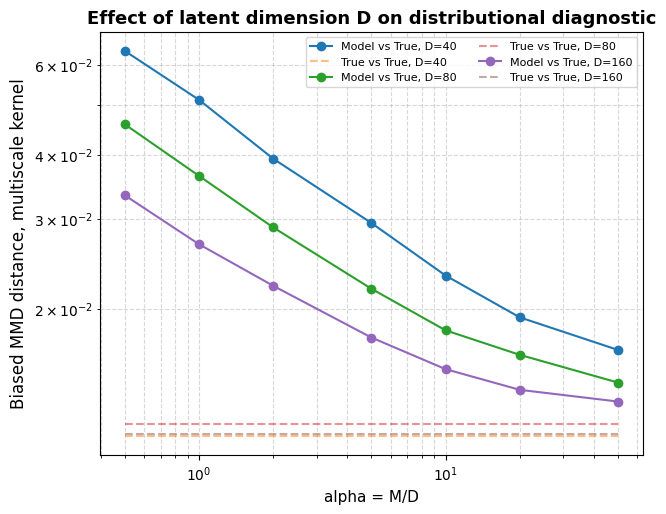

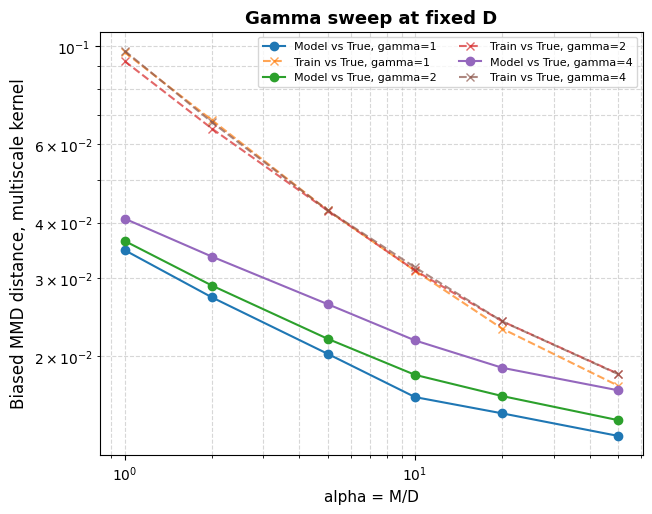

In [8]:
df_B = df[df["experiment"] == "B"].copy()

if not df_B.empty:
    unique_D_B = sorted(df_B["D"].unique())

    plt.figure(figsize=(7, 5.5))
    for d_val in unique_D_B:
        sub_d = df_B[df_B["D"] == d_val]
        sub = grouped_mean_sem(sub_d, ["alpha"], "mmd_biased_multiscale").sort_values("alpha")
        base = grouped_mean_sem(sub_d, ["alpha"], "baseline_mmd_biased_multiscale").sort_values("alpha")
        plt.plot(sub["alpha"], sub["mean"], linestyle="-", marker="o", label=f"Model vs True, D={d_val}")
        plt.plot(base["alpha"], base["mean"], linestyle="--", alpha=0.5, label=f"True vs True, D={d_val}")

    plt.xscale("log")
    plt.yscale("log", nonpositive="clip")
    plt.xlabel("alpha = M/D", fontsize=11)
    plt.ylabel("Biased MMD distance, multiscale kernel", fontsize=12)
    plt.title("Effect of latent dimension D on distributional diagnostic", fontsize=13, fontweight="bold")
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.legend(loc="best", fontsize=8, ncol=2)
    plt.savefig("figures/fig_mmd_vs_alpha_D_sweep.png", bbox_inches="tight")
    plt.show()
else:
    print("No Experiment B data available.")

# Optional gamma sweep.
df_C = df[df["experiment"] == "C"].copy()
if not df_C.empty:
    plt.figure(figsize=(7, 5.5))
    for gamma_val in sorted(df_C["gamma"].unique()):
        sub_g = df_C[df_C["gamma"] == gamma_val]
        sub = grouped_mean_sem(sub_g, ["alpha"], "mmd_biased_multiscale").sort_values("alpha")
        train_true = grouped_mean_sem(sub_g, ["alpha"], "train_true_mmd_biased_multiscale").sort_values("alpha")
        plt.plot(sub["alpha"], sub["mean"], linestyle="-", marker="o", label=f"Model vs True, gamma={gamma_val:g}")
        plt.plot(train_true["alpha"], train_true["mean"], linestyle="--", marker="x", alpha=0.7, label=f"Train vs True, gamma={gamma_val:g}")

    plt.xscale("log")
    plt.yscale("log", nonpositive="clip")
    plt.xlabel("alpha = M/D", fontsize=11)
    plt.ylabel("Biased MMD distance, multiscale kernel", fontsize=12)
    plt.title("Gamma sweep at fixed D", fontsize=13, fontweight="bold")
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.legend(loc="best", fontsize=8, ncol=2)
    plt.savefig("figures/fig_mmd_vs_alpha_gamma_sweep.png", bbox_inches="tight")
    plt.show()
else:
    print("No Experiment C gamma-sweep data available.")


## 12. Training sanity checks and empirical-distribution diagnostics

Secondary diagnostics:

1. **BCE train/test loss**: verifies that the denoising optimization is not obviously failing.
2. **Model-vs-True / Train-vs-True / True-vs-True**: separates generated-distribution quality from finite empirical training-set quality.
3. **Model-vs-Train**: a proximity-to-empirical-train diagnostic, not a direct memorization proof.
4. **Nearest training overlap**: a more direct memorization proxy based on the largest overlap between generated samples and training samples.


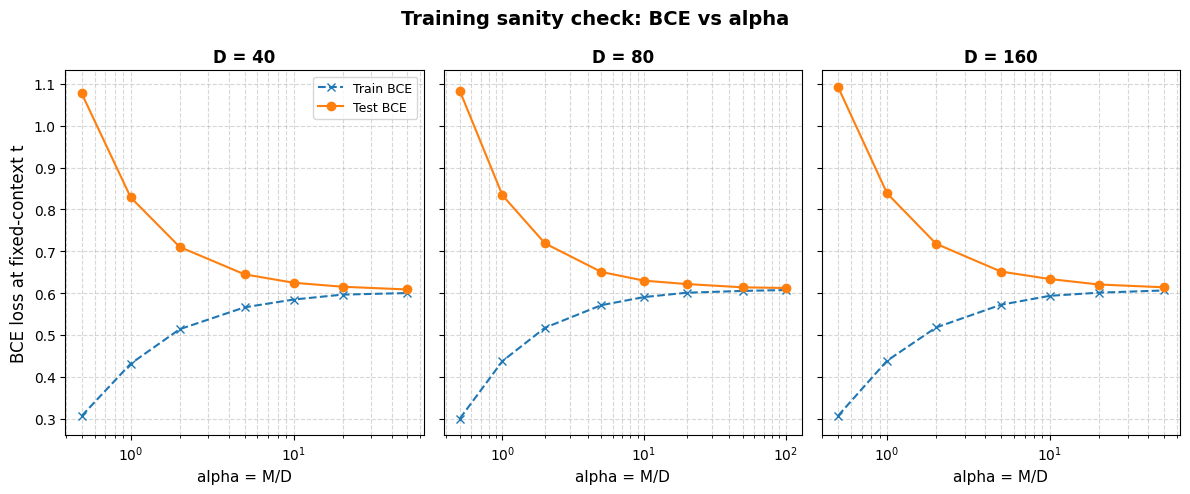

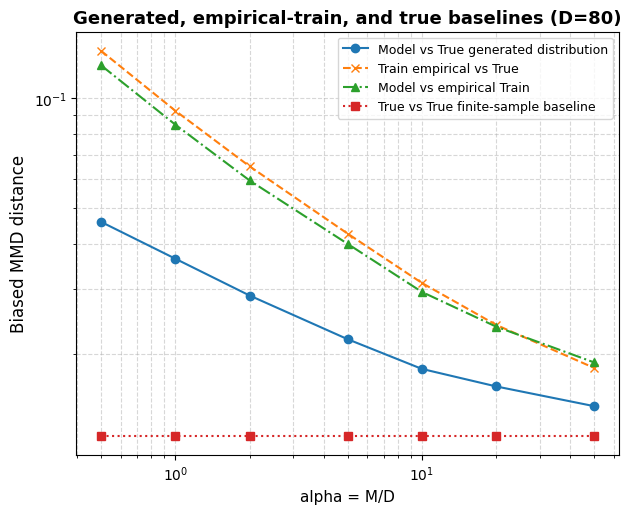

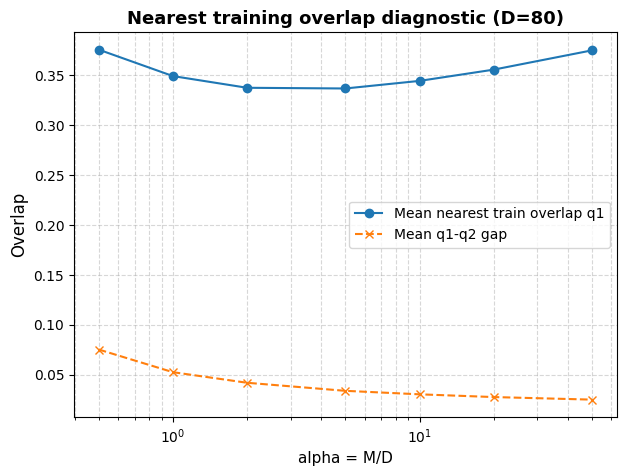

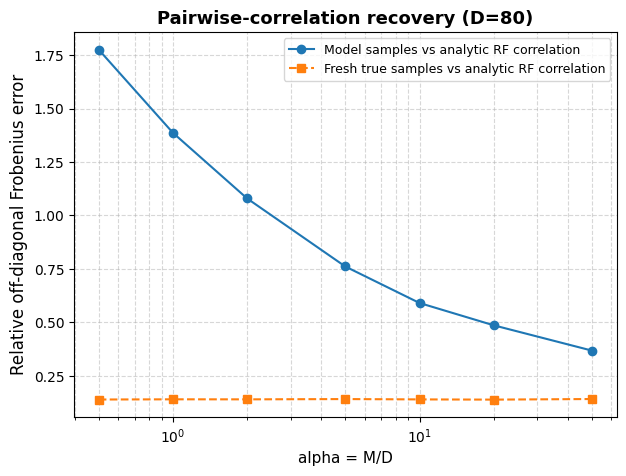

In [9]:
# Plot 4: BCE losses.
unique_D_all = sorted(df["D"].unique())
fig, axes = plt.subplots(1, len(unique_D_all), figsize=(4 * len(unique_D_all), 5), sharey=True)
if len(unique_D_all) == 1:
    axes = [axes]

for idx, d_val in enumerate(unique_D_all):
    ax = axes[idx]
    sub_d = df[(df["D"] == d_val) & (df["gamma"] == 2.0)]

    if not sub_d.empty:
        sub_avg = sub_d.groupby("alpha")[["train_loss", "test_loss"]].mean().reset_index()
        ax.plot(sub_avg["alpha"], sub_avg["train_loss"], linestyle="--", marker="x", label="Train BCE")
        ax.plot(sub_avg["alpha"], sub_avg["test_loss"], linestyle="-", marker="o", label="Test BCE")

    ax.set_xscale("log")
    ax.set_xlabel("alpha = M/D", fontsize=11)
    ax.set_title(f"D = {d_val}", fontsize=12, fontweight="bold")
    ax.grid(True, which="both", linestyle="--", alpha=0.5)
    if idx == 0:
        ax.set_ylabel("BCE loss at fixed-context t", fontsize=12)
        ax.legend(loc="best", fontsize=9)

plt.suptitle("Training sanity check: BCE vs alpha", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/fig_bce_sanity.png", bbox_inches="tight")
plt.show()

# Plot 5: empirical distribution diagnostics.
rep_D_all = 80 if 80 in unique_D_all else unique_D_all[0]
df_rep = df[(df["D"] == rep_D_all) & (df["gamma"] == 2.0) & (df["experiment"] == "B")]

if not df_rep.empty:
    plt.figure(figsize=(7, 5.5))
    for col_name, label, style in [
        ("mmd_biased_multiscale", "Model vs True generated distribution", "-o"),
        ("train_true_mmd_biased_multiscale", "Train empirical vs True", "--x"),
        ("model_train_mmd_biased_multiscale", "Model vs empirical Train", "-.^"),
        ("baseline_mmd_biased_multiscale", "True vs True finite-sample baseline", ":s"),
    ]:
        sub = grouped_mean_sem(df_rep, ["alpha"], col_name).sort_values("alpha")
        plt.plot(sub["alpha"], sub["mean"], style, label=label)

    plt.xscale("log")
    plt.yscale("log", nonpositive="clip")
    plt.xlabel("alpha = M/D", fontsize=11)
    plt.ylabel("Biased MMD distance", fontsize=12)
    plt.title(f"Generated, empirical-train, and true baselines (D={rep_D_all})", fontsize=13, fontweight="bold")
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.legend(loc="best", fontsize=9)
    plt.savefig("figures/fig_empirical_distribution_diagnostics.png", bbox_inches="tight")
    plt.show()

    # Nearest-neighbor memorization proxy.
    if "nearest_train_q1_mean" in df_rep.columns:
        plt.figure(figsize=(7, 5.0))
        sub = grouped_mean_sem(df_rep, ["alpha"], "nearest_train_q1_mean").sort_values("alpha")
        plt.plot(sub["alpha"], sub["mean"], linestyle="-", marker="o", label="Mean nearest train overlap q1")
        if "nearest_train_q1_q2_gap_mean" in df_rep.columns:
            gap = grouped_mean_sem(df_rep, ["alpha"], "nearest_train_q1_q2_gap_mean").sort_values("alpha")
            plt.plot(gap["alpha"], gap["mean"], linestyle="--", marker="x", label="Mean q1-q2 gap")
        plt.xscale("log")
        plt.xlabel("alpha = M/D", fontsize=11)
        plt.ylabel("Overlap", fontsize=12)
        plt.title(f"Nearest training overlap diagnostic (D={rep_D_all})", fontsize=13, fontweight="bold")
        plt.grid(True, which="both", linestyle="--", alpha=0.5)
        plt.legend(loc="best", fontsize=10)
        plt.savefig("figures/fig_nearest_train_overlap.png", bbox_inches="tight")
        plt.show()

    # Pairwise-correlation structural diagnostic.
    if "corr_relerr_model_true" in df_rep.columns:
        plt.figure(figsize=(7, 5.0))
        for col_name, label, style in [
            ("corr_relerr_model_true", "Model samples vs analytic RF correlation", "-o"),
            ("corr_relerr_fresh_true", "Fresh true samples vs analytic RF correlation", "--s"),
        ]:
            sub = grouped_mean_sem(df_rep, ["alpha"], col_name).sort_values("alpha")
            plt.plot(sub["alpha"], sub["mean"], style, label=label)
        plt.xscale("log")
        plt.xlabel("alpha = M/D", fontsize=11)
        plt.ylabel("Relative off-diagonal Frobenius error", fontsize=12)
        plt.title(f"Pairwise-correlation recovery (D={rep_D_all})", fontsize=13, fontweight="bold")
        plt.grid(True, which="both", linestyle="--", alpha=0.5)
        plt.legend(loc="best", fontsize=9)
        plt.savefig("figures/fig_pairwise_correlation_error.png", bbox_inches="tight")
        plt.show()


## 13. Interpretation and discussion

The correct interpretation is conservative:

- **BCE vs. MMD mismatch**: A smaller masked-coordinate BCE does not automatically imply that the full generative sampler has the correct joint distribution. BCE is a local conditional diagnostic; MMD compares generated samples with true samples globally.
- **MMD vs. $\alpha$**: If Model-vs-True MMD decreases with $\alpha=M/D$, this is evidence that the generated distribution becomes closer to the true finite-$F$ hidden-manifold law as more training samples are provided.
- **Train-vs-True baseline**: This baseline tells us whether the model is doing better or worse than the empirical training distribution as an approximation to $P_F$. It is essential for separating generalization from finite-sample memorization.
- **Plateau warning**: A residual gap above the True-vs-True baseline is compatible with limited linear-model capacity, but it does not prove it. The gap may also come from optimization error, fixed-mask training mismatch, sampler bias, finite-sample MMD effects, or the chosen kernel scale.
- **Linear backbone caveat**: The hidden-manifold sign model induces nontrivial dependencies among visible bits. A time-independent linear visible-coordinate denoiser may capture part of the structure but need not represent the full family of masked conditional distributions required to reproduce $P_F$.
- **Negative unbiased estimates**: Raw unbiased MMD$^2$ can be slightly negative at finite sample size when two samples are drawn from close or identical distributions. This is expected statistical noise, not a bug.


## 14. Limitations and next steps

1. **Objective mismatch**: If `TRAINING_OBJECTIVE="fixed_context"`, the model is trained at one masking level. This matches the finite-$K$ sanity-check setup but differs from the repo's full $t\sim U(0,1)$ masked-diffusion objective. Run `repo_uniform_t` before making claims about the repo's canonical model.
2. **Model expressivity**: The linear model may be misspecified for the hidden-manifold sign law. Test `tensor4`/`tensor8` for mask-fraction dependence and `rfs5_tanh`/`rfs10_tanh` for nonlinear score capacity.
3. **Sampler dependence**: The generated law is $P_{\theta,k}$, not just $P_\theta$. Repeat with larger $k$ and one-shot sampling to test whether performance relies on slow sequential correction.
4. **Finite update budget**: Fixed optimization steps across dimensions can confound conclusions because changing $D$ changes $N$, $M$, and parameter count.
5. **Repeats**: A final result should set `FINAL_RUN=True` to use multiple repeats over feature matrices, datasets, model initialization, and sampling noise.
6. **Additional structural diagnostics**: Pairwise-correlation recovery and overlap histograms should be inspected alongside MMD, because MMD is a scalar summary and can hide failure modes.


In [10]:
# Print run status
print("=== Execution Run Status ===")
print("FAST_DEBUG:", FAST_DEBUG)
print("FINAL_RUN:", FINAL_RUN)
print("TRAINING_OBJECTIVE:", TRAINING_OBJECTIVE)
print("sample_k:", sample_k)
print("n_repeats:", n_repeats)
print("n_mmd_samples:", n_mmd_samples)
print("D values actually run:", sorted(df["D"].unique()))
print("gamma values actually run:", sorted(df["gamma"].unique()))
print("alpha values actually run:", sorted(df["alpha"].unique()))
print("number of rows:", len(df))
print("============================")

if FAST_DEBUG:
    print("\n[Warning] The notebook was run in FAST_DEBUG mode. The output is for code verification only and must not be used to draw research conclusions.")
if not FINAL_RUN:
    print("\n[Warning] FINAL_RUN=False. The notebook uses one repeat by default. Set FINAL_RUN=True before making final quantitative claims.")


=== Execution Run Status ===
FAST_DEBUG: False
FINAL_RUN: False
TRAINING_OBJECTIVE: fixed_context
sample_k: 1
n_repeats: 1
n_mmd_samples: 10000
D values actually run: [np.int64(40), np.int64(80), np.int64(160)]
gamma values actually run: [np.float64(1.0), np.float64(2.0), np.float64(4.0)]
alpha values actually run: [np.float64(0.5), np.float64(1.0), np.float64(2.0), np.float64(5.0), np.float64(10.0), np.float64(20.0), np.float64(50.0), np.float64(100.0)]
number of rows: 47

[Warning] FINAL_RUN=False. The notebook uses one repeat by default. Set FINAL_RUN=True before making final quantitative claims.
